**Data Cleaning and Processing**

EPIC - RL2 - SP3

Paulo Yoshio Kuga

In [5]:
import lissa as li
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [6]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")

Pumps : #38
Runs: #57


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


In [7]:
pump = "B-18 2"
exportData = (baseData.loc[baseData["Well Run"] == pump].copy()) #copies the original dataset

exportData["Tempo"] = pd.to_datetime(exportData["time"])
exportData.set_index("Tempo",drop=True,inplace=True)

Headers = [
'ESP discharge temperature sensor',
'ESP intake temperature',
'ESP motor temperature',
'Well head Temperature',
'ESP intake Pressure',
'ESP discharge pressure',
'ESP differential pressure',
'Well head pressure',
'VSD power frequency',
'ESP Motor Voltage',
"ESP Vibration X",
"ESP Vibration Y"
#'Current Mean',
#'ESP Vibration Module',
#'ESP Power',

]

exportData[Headers].plot(figsize=(20,10),fontsize=15)

# plt.figure(figsize=(20,10))
# plt.scatter(exportData.index,exportData["ESP Motor Voltage"])

plt.legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
plt.title("Propriedades da corrida " + pump,fontsize=20)
plt.tight_layout(pad=1.1)
plt.xlabel("Tempo",fontsize=15)
plt.savefig("../imagens_gerais/crude_data",bbox_inches='tight')
plt.close()


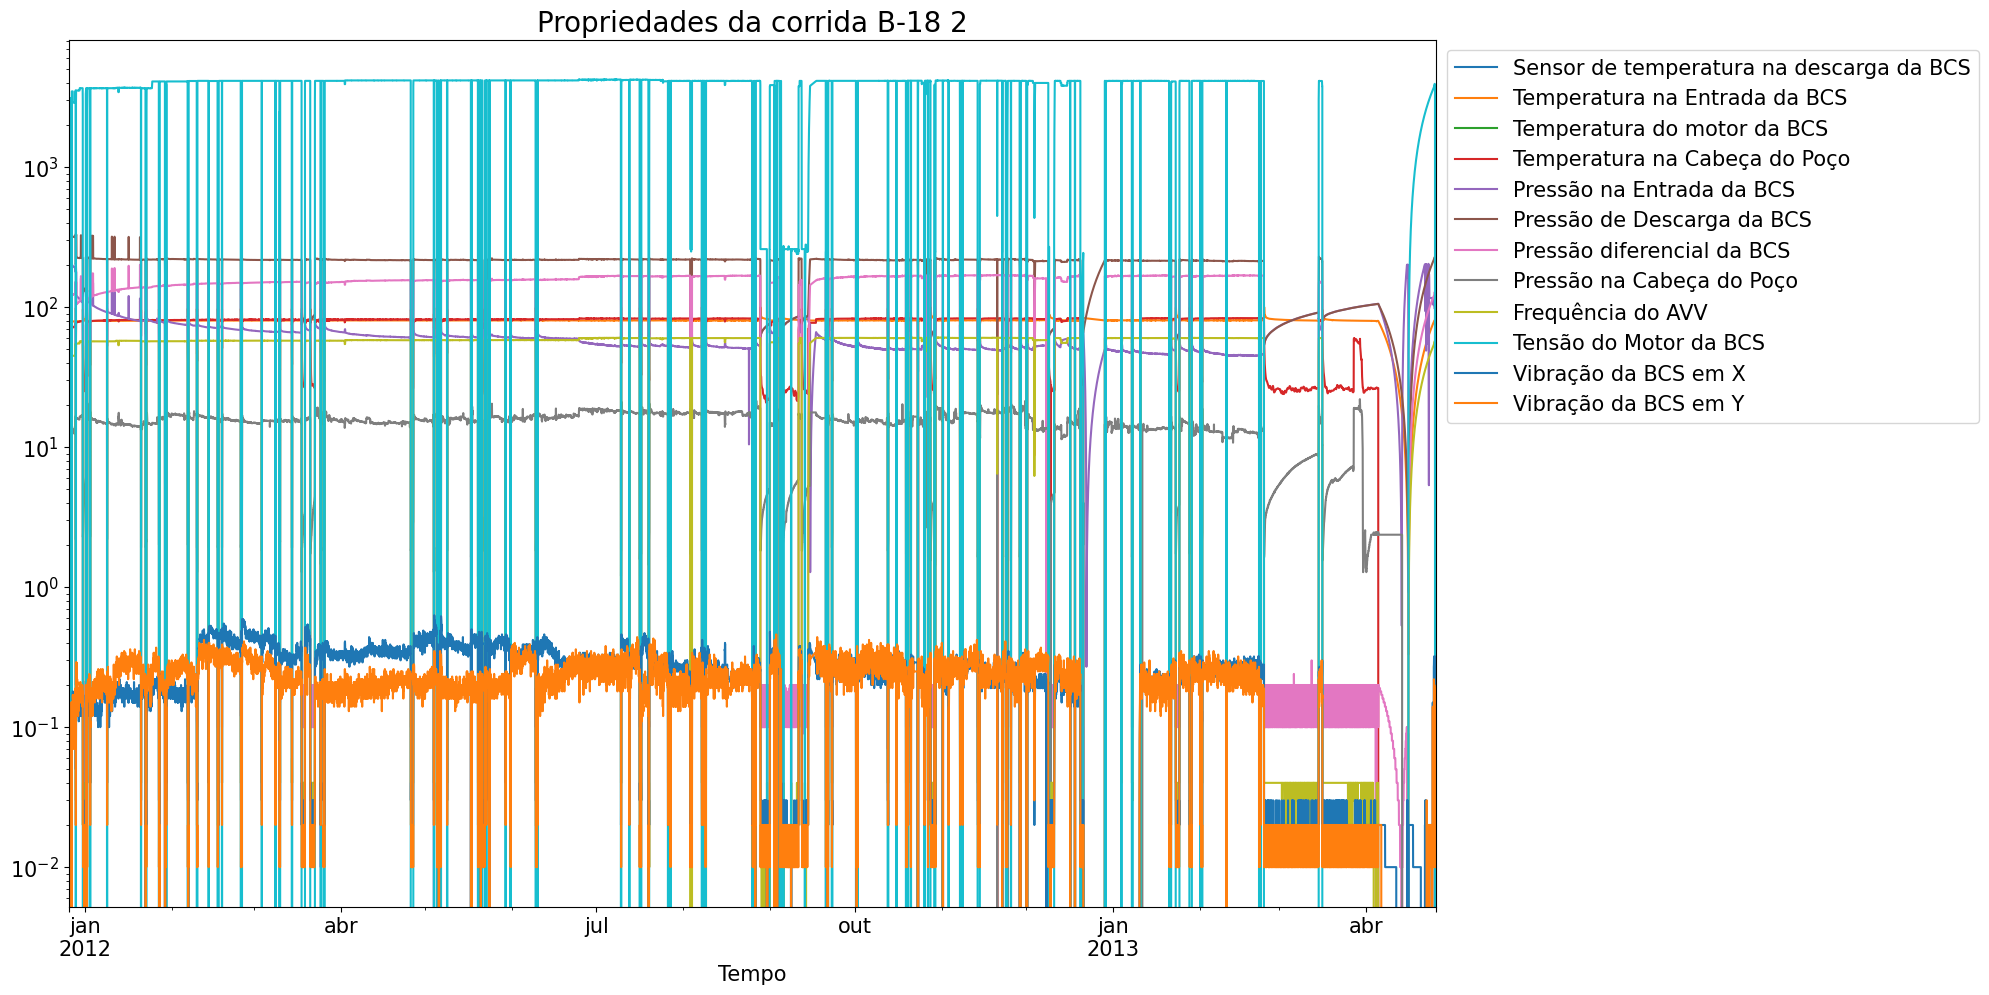

In [12]:
exportData[Headers].plot(figsize=(20,10),logy=True,fontsize=15)

plt.legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
plt.title("Propriedades da corrida " + pump,fontsize=20)
plt.tight_layout(pad=1.1)
plt.xlabel("Tempo",fontsize=15)
plt.savefig("../imagens_gerais/crude_data_log",bbox_inches='tight')
#plt.close()

In [5]:
li.PropertyTableGenerator(
    (baseData.isna().sum(axis=0)/baseData.shape[0]).reset_index(),
    name="tabela_vazios.csv"
    ) #tabela vazios


li.PropertyTableGenerator(
    entireData.describe().T[["mean","std"]],
    name="tabela_posprocessamento.csv"
    ) #tabela vazios

li.PropertyTableGenerator(
    baseData.describe().T[["mean","std"]],
    path="./",name="propriedades.csv")


,index,mean,std,Unidade
0,Corrente do motor - Fase A,62.889113,50.871716,A
1,Corrente do motor - Fase B,64.176819,51.769127,A
2,Corrente do motor - Fase C,62.781432,51.241704,A
3,Frequência do AVV,35.669178,28.126207,Hz
4,Temperatura do motor da BCS,103.555230,25.108982,ºC
5,Pressão diferencial da BCS,83.994517,73.419641,Bar
6,Pressão na Entrada da BCS,119.975201,55.672190,Bar
7,Fração de água @,48.312428,31.897245,%
8,Temperatura na Entrada da BCS,81.402356,7.918445,ºC
9,Pressão de Descarga da BCS,211.483190,43.465711,Bar


In [6]:
pump = "B-18 2"
exportData = (entireData.loc[entireData["Well Run"] == pump].copy()) #copies the original dataset

Headers = [
#'ESP discharge temperature sensor',
'ESP intake temperature',
'ESP motor temperature',
'Well head Temperature',
'ESP intake Pressure',
'ESP discharge pressure',
#'ESP differential pressure',
'Well head pressure',
'VSD power frequency',
'ESP Motor Voltage',
'ESP Current Module',
'ESP Vibration Module',
#'ESP Power',
#"ESP Vibration X",
#"ESP Vibration Y"
]

#Filter = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*windowSize).mean()-x.expanding().median())/x.expanding().std())

Measure = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*1).mean()-x.expanding().median()))
MAD = Measure.apply(lambda x: x.abs().expanding().median())

# Filter = SeriesBack(Measure)/SeriesBack(MAD)


Z = li.SeriesBack(Measure)/(li.SeriesBack(MAD)*1.4826)

removedHeaders = [
    'Water Cut @ 20degC - 1 atm',
    'Choke Opening',
    "Well aligned to Train A",
    "Well aligned to Train B",
    'Failure Info',
    'Pump Info',
    "Well Run",
    "Failure",
    "Well_down"
    
    ]

data = pd.merge(Z,exportData[removedHeaders],how="left",on="time")

fig,axs = plt.subplots(2,1,figsize=(20,10))

plt.rcParams["font.size"]=15



exportData[Headers].expanding().std().plot(ax=axs[0],logy=True,sharex=True)
axs[0].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[0].title.set_text("Desvio Padrão")#"Standard Deviation")
axs[0].title.set_fontsize(20)


(li.SeriesBack(MAD)*1.4826)[Headers].plot(ax=axs[1],logy=True)
axs[1].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[1].title.set_text("Desvio Absoluto - MAD")#"Mean Absolute Deviation")
axs[1].title.set_fontsize(20)
plt.tight_layout(pad=1.1)
axs[1].set_xlabel("Tempo")

fig.savefig("../imagens_gerais/madvsnormal_pt.jpg",bbox_inches='tight')
plt.close()


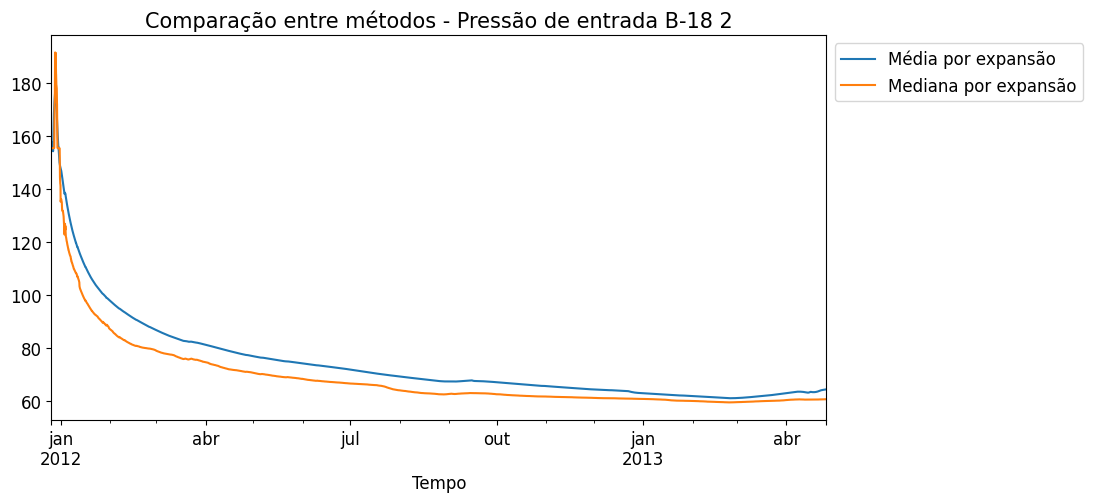

In [16]:
plt.rcParams["font.size"]=12
fig,axs = plt.subplots(1,1,figsize=(10,5))
exportData["ESP intake Pressure"].expanding().mean().plot(ax=axs)
exportData["ESP intake Pressure"].expanding().median().plot(ax=axs)

axs.title.set_text("Comparação entre métodos - Pressão de entrada B-18 2")#"Standard Deviation")
axs.title.set_fontsize(15)

axs.legend(["Média por expansão","Mediana por expansão"],loc='upper left',bbox_to_anchor=(1, 1),fontsize=12)


# axs[1].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
# axs[1].title.set_text("Mediana por Expansão")#"Mean Absolute Deviation")
# axs[1].title.set_fontsize(20)
# plt.tight_layout(pad=1.1)
# axs[1].set_xlabel("Tempo")

fig.savefig("../imagens_gerais/meanvsmedian_pt.jpg",bbox_inches='tight')
#plt.close()

In [8]:
baseDataHeaders = [
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP motor Current - phase A',
    'ESP motor Current - phase B',
    'ESP motor Current - phase C',
    'ESP Vibration X',
    'ESP Vibration Y'
    ]


Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration X',
    #'ESP Vibration Y'
    "ESP Vibration Module"
    #'ESP Power'

    ]

In [9]:
percentual = ((entireData[Headers]-entireData[Headers].min(axis=0))/(entireData[Headers].max(axis=0)-entireData[Headers].min(axis=0)))

percentual.describe().T

,count,mean,std,min,25%,50%,75%,max
ESP intake temperature,1254646.0,0.414539,0.040334,0.0,0.409535,0.419061,0.427669,1.0
ESP motor temperature,1223111.0,0.676858,0.041305,0.0,0.640379,0.682427,0.704749,1.0
Well head Temperature,1350750.0,0.506119,0.251872,0.0,0.236696,0.682696,0.713043,1.0
ESP intake Pressure,1252917.0,0.335442,0.069116,0.0,0.281059,0.321804,0.397497,1.0
ESP discharge pressure,1254423.0,0.492933,0.101316,0.0,0.477332,0.523857,0.550663,1.0
Well head pressure,1350750.0,0.052076,0.033594,0.0,0.031615,0.056154,0.066000,1.0
VSD power frequency,1362103.0,0.509560,0.401803,0.0,0.000143,0.771571,0.857714,1.0
ESP Motor Voltage,1362103.0,0.492671,0.385727,0.0,0.000000,0.754718,0.824445,1.0
ESP Current Module,1362103.0,0.026362,0.021342,0.0,0.000000,0.035675,0.045663,1.0
ESP Vibration Module,1353798.0,0.004019,0.006775,0.0,0.000458,0.002748,0.004871,1.0


In [10]:
#pd.plotting.boxplot_frame(percentual,figsize=(20,10))

In [11]:
fig,axes = li.Histogram(
    entireData.loc[entireData["Well_down"]==0][Headers],
    "Histogramas dos dados originais",figsizeT=(20,18),layout=(4,3))

plt.savefig("../imagens_gerais/hist_original.jpg",bbox_inches='tight')
plt.close()

In [12]:
boxplot_data = entireData.loc[entireData["Well_down"]==0][Headers].copy().fillna(0)
#boxplot_data["ESP Motor Voltage"] = boxplot_data["ESP Motor Voltage"]/1000
pd.plotting.boxplot(((boxplot_data-boxplot_data.min())/(boxplot_data.max()-boxplot_data.min())),figsize=(30,10))


plt.rcParams["font.size"]=20
plt.suptitle("Diagramas de Caixa dos dados Originais",fontsize=20) #Original Data BoxPlots" 
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/boxplot_original.jpg",bbox_inches='tight')
plt.close()

In [28]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,2,figsize=(15,6),sharex=True)
plt.rcParams["font.size"]=10


pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[0,0],color="blue")

pumpData["ESP intake Pressure"].expanding().median().plot(ax=axs[0,1])
pumpData["ESP intake Pressure"].expanding().std().plot(ax=axs[1,0],color="orange")


pumpTotalData["ESP intake Pressure"].plot(ax=axs[1,1],color="red")



# axs[0,0].set_xlabel("time")
# axs[1,1].set_xlabel("time")

axs[0,0].set_ylabel("[bar]")
axs[0,1].set_ylabel("[bar]")
axs[1,0].set_ylabel("[bar]")
axs[1,1].set_ylabel("[-]")

# axs[0,0].set_title("Filtered Signal",fontsize=9)
# axs[0,1].set_title("Expanding Median",fontsize=9)
# axs[1,0].set_title("Expanding Standard-Deviation",fontsize=9)
# axs[1,1].set_title("Normalized Signal",fontsize=9)
# fig.suptitle("ESP intake Pressure - Run: " + pump)
# plt.tight_layout()



# plt.savefig("../imagens_gerais/z_score_formation.jpg")
# plt.close()

axs[1,0].set_xlabel("Tempo")
axs[1,1].set_xlabel("Tempo")



axs[0,0].set_title("Sinal Filtrado",fontsize=9)
axs[0,1].set_title("Mediana por Expansão",fontsize=9)
axs[1,0].set_title("Desvio-padrão por expansão",fontsize=9)
axs[1,1].set_title("Sinal Normalizado",fontsize=9)
fig.suptitle("Pressão na Entrada da ESP - Corrida: " + pump)

plt.savefig("../imagens_gerais/z_score_formation_pt.jpg",bbox_inches='tight')
plt.close()


In [14]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumpTotalData["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered and Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg",bbox_inches='tight')
plt.close()


In [15]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("Tempo")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Sinal Original",fontsize=9)
axs[1].set_title("Sinal Filtrado",fontsize=9)
fig.suptitle("Pressão de Entrada na corrida: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2_pt.jpg",bbox_inches='tight')
plt.close()



In [16]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg",bbox_inches='tight')
plt.close()


In [27]:
plt.rcParams["font.size"]=12
li.ZScorePlot(totalData,pump,Headers)
plt.legend([li.Traducao(item) for item in Headers])
plt.suptitle("Dados da corrida "+ pump + " com o Z-score modificado",fontsize=16)
plt.xlabel("Tempo")

plt.savefig("../imagens_gerais/Zscore.jpg", bbox_inches='tight')

plt.close()


In [26]:
x = entireData.loc[entireData["Well_down"]==0][Headers]

Z = (x - x.mean())/x.std()

axes = Z.hist(bins=100,figsize=(20,8),density=True,layout=(2,5))

i = 0
measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","kV","A","g","g","-"]

for ax in axes.flatten():
    ax.set_title(li.Traducao(ax.get_title()))
    ax.set_xlabel("Valores [-]" )  # Define a legenda com o nome da coluna
    ax.set_ylabel("Densidade")
    ax.set_xlim([-6,6])
    i += 1


plt.suptitle("Histogramas dos dados originais",fontsize=20)
plt.tight_layout(pad=1.6)
plt.savefig("../imagens_gerais/Z-hist.jpg",bbox_inches='tight')
plt.close()

In [25]:
fig, axs = li.QQPlots(Z,Headers,lineType="45",english=False, titleFontsize=20,ydist=0.99,figSizeSt=(20,10),generalFontSize=12, title="Gráfico QQ")
fig.savefig("../imagens_gerais/QQplot_pt",bbox_inches='tight')
plt.close()

In [20]:
# x = totalData.loc[totalData["Well_down"]==0][Headers].apply(np.log1p).abs()

# axes = x.hist(bins=100,figsize=(20,20),density=True)

# i = 0
# measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","kV","A","g","g","-"]


# for ax in axes.flatten():
#     ax.set_title(li.Traducao(ax.get_title()))
#     ax.set_xlabel("Valores [" +measures[i]+"]" )  # Define a legenda com o nome da coluna
#     ax.set_ylabel("Densidade")
#     #ax.set_xlim([-6,6])
#     i += 1


# plt.suptitle("Histogramas dos dados originais",fontsize=20)
# plt.tight_layout(pad=1.6)
# #plt.savefig("../imagens_gerais/Z-hist.jpg")